In [1]:
##1.Imports and upload
import pandas as pd                 # data cleaning and analysis
import numpy as np                  # numeric helpers
import matplotlib.pyplot as plt     # base plotting library
import seaborn as sns               # nicer statistical charts
import sqlite3                      # lets us run SQL on our data
import os                           # create folders
from google.colab import files      # upload/download in Colab

sns.set_theme(style="whitegrid")    # clean default chart style

uploaded = files.upload()           # opens a file picker: choose your CSV
file_name = list(uploaded.keys())[0]  # take the name of the uploaded file
print("Loaded file:", file_name)

Saving Sample data (1).xlsx - Sheet1.csv to Sample data (1).xlsx - Sheet1.csv
Loaded file: Sample data (1).xlsx - Sheet1.csv


In [2]:
##2.Load and inspect
# keep_default_na=False stops pandas from turning the text "None" into NaN.
# Your Discount Band column can contain "None" as a real category.
df = pd.read_csv(file_name, keep_default_na=False, na_values=[""])

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,None,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,1-Dec-14,12,December,2014
1,Government,Germany,Paseo,None,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,1-Jun-14,6,June,2014
2,Government,Canada,Paseo,None,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,1-Nov-13,11,November,2013
3,Government,Germany,Paseo,None,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,1-Dec-14,12,December,2014
4,Government,Germany,Velo,None,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,1-Jun-14,6,June,2014


In [3]:
df.info()                 # column names, data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        700 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [4]:
print(df.columns.tolist())   # note: " Sales" has a leading space in your file
df.describe()                # min/max/mean of numeric columns

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,7.900000,2013.750000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,3.377321,0.433322
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,12.000000,2014.000000


In [5]:
##3.# 1. Clean column names: strip spaces, replace inner spaces with underscores
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns.tolist())

# 2. Strip stray spaces from text columns
text_cols = ["Segment", "Country", "Product", "Discount_Band", "Month_Name"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 3. Missing values and duplicates
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold', 'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name', 'Year']

Missing values per column:
 Segment                0
Country                0
Product                0
Discount_Band          0
Units_Sold             0
Manufacturing_Price    0
Sale_Price             0
Gross_Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month_Number           0
Month_Name             0
Year                   0
dtype: int64

Duplicate rows: 0


In [6]:
# 4. Convert Date to a real datetime.
# We try month-first, then day-first, and keep whichever matches Month_Number.
for dayfirst in (False, True):
    parsed = pd.to_datetime(df["Date"], dayfirst=dayfirst, errors="coerce")
    if (parsed.dt.month == df["Month_Number"]).mean() > 0.99:
        df["Date"] = parsed
        print("Date parsed with dayfirst =", dayfirst)
        break
else:
    print("Warning: Date format didn't match Month_Number, check manually")

# 5. Make sure numeric columns are numeric
num_cols = ["Units_Sold", "Manufacturing_Price", "Sale_Price",
            "Gross_Sales", "Discounts", "Sales", "COGS", "Profit"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Date parsed with dayfirst = False


/tmp/ipykernel_676/1225150343.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df["Date"], dayfirst=dayfirst, errors="coerce")


In [7]:
# 6. Sanity checks: do the numbers add up?
# Sales should equal Gross_Sales - Discounts, and Profit = Sales - COGS
bad_sales  = (~np.isclose(df["Gross_Sales"] - df["Discounts"], df["Sales"], atol=1)).sum()
bad_profit = (~np.isclose(df["Sales"] - df["COGS"], df["Profit"], atol=1)).sum()
print("Rows where Sales doesn't match:", bad_sales)
print("Rows where Profit doesn't match:", bad_profit)

# 7. How many loss-making rows?
print("Loss-making rows:", (df["Profit"] < 0).sum())

# 8. New useful columns
df["Profit_Margin_%"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"] * 100, np.nan)
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

print("\nFinal shape:", df.shape)
df.head()

Rows where Sales doesn't match: 0
Rows where Profit doesn't match: 0
Loss-making rows: 58

Final shape: (700, 18)


,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Date,Month_Number,Month_Name,Year,Profit_Margin_%,Year_Month
0,Government,Germany,Carretera,None,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014,25.714286,2014-12
1,Government,Germany,Paseo,None,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014,25.714286,2014-06
2,Government,Canada,Paseo,None,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013,25.714286,2013-11
3,Government,Germany,Paseo,None,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014,25.714286,2014-12
4,Government,Germany,Velo,None,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014,25.714286,2014-06


In [8]:
##4.Analysis with Pandas
# Overall KPIs
kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Units Sold": df["Units_Sold"].sum(),
    "Total Discounts": df["Discounts"].sum(),
    "Overall Profit Margin %": df["Profit"].sum() / df["Sales"].sum() * 100,
}
for k, v in kpis.items():
    print(f"{k}: {v:,.2f}")

Total Sales: 118,726,350.26
Total Profit: 16,893,702.26
Total Units Sold: 1,125,806.00
Total Discounts: 9,205,248.24
Overall Profit Margin %: 14.23


In [9]:
# Helper: group by one column and summarise sales, profit and margin
def summarize(by):
    out = df.groupby(by).agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units=("Units_Sold", "sum")
    )
    out["Margin_%"] = out["Profit"] / out["Sales"] * 100
    return out.sort_values("Profit", ascending=False).round(2)

by_segment  = summarize("Segment");       display(by_segment)
by_country  = summarize("Country");       display(by_country)
by_product  = summarize("Product");       display(by_product)
by_discount = summarize("Discount_Band"); display(by_discount)

,Sales,Profit,Units,Margin_%
Segment,,,,
Government,52504260.67,11388173.17,470673.5,21.69
Small Business,42427918.50,4143168.50,153139.0,9.77
Channel Partners,1800593.64,1316803.14,161263.5,73.13
Midmarket,2381883.08,660103.07,172178.0,27.71
Enterprise,19611694.38,-614545.62,168552.0,-3.13


,Sales,Profit,Units,Margin_%
Country,,,,
France,24354172.28,3781020.78,240931.0,15.53
Germany,23505340.82,3680388.82,201494.0,15.66
Canada,24887654.88,3529228.88,247428.5,14.18
United States of America,25029830.16,2995540.66,232627.5,11.97
Mexico,20949352.11,2907523.11,203325.0,13.88


,Sales,Profit,Units,Margin_%
Product,,,,
Paseo,33011143.95,4797437.95,338239.5,14.53
VTT,20511921.02,3034608.02,168783.0,14.79
Amarilla,17747116.06,2814104.06,155315.0,15.86
Velo,18250059.46,2305992.46,162424.5,12.64
Montana,15390801.88,2114754.88,154198.0,13.74
Carretera,13815307.88,1826804.88,146846.0,13.22


,Sales,Profit,Units,Margin_%
Discount_Band,,,,
Low,34629778.70,6188857.70,261858.5,17.87
Medium,38780430.84,5579522.84,379698.5,14.39
High,37372486.72,3388866.72,398085.5,9.07
None,7943654.00,1736455.00,86163.5,21.86


In [10]:
# Yearly and monthly trends
by_year = summarize("Year").sort_index();           display(by_year)
monthly = df.groupby("Year_Month")[["Sales", "Profit"]].sum().round(2)
display(monthly.head(12))

# Best combination of Segment + Product
display(df.groupby(["Segment", "Product"])["Profit"].sum()
          .sort_values(ascending=False).head(10).round(2))

,Sales,Profit,Units,Margin_%
Year,,,,
2013,26415255.51,3878464.51,264674.0,14.68
2014,92311094.75,13015237.75,861132.0,14.10


,Sales,Profit
Year_Month,,
2013-09,4484000.03,763603.03
2013-10,9295611.10,1657795.10
2013-11,7267203.30,765502.30
2013-12,5368441.08,691564.08
2014-01,6607761.68,814028.68
2014-02,7297531.39,1148547.39
2014-03,5586859.87,669866.87
2014-04,6964775.07,929984.57
2014-05,6210211.06,828640.06


Segment         Product  
Government      Paseo        3057290.70
                Amarilla     2208301.61
                VTT          1840653.71
                Velo         1756732.05
                Carretera    1398994.08
Small Business  Paseo        1231309.50
Government      Montana      1126201.02
Small Business  VTT           982150.00
                Montana       743313.50
                Velo          431102.50
Name: Profit, dtype: float64

In [11]:
##5.Analysis with SQL
conn = sqlite3.connect(":memory:")                 # temporary in-memory database
df.to_sql("sales", conn, index=False, if_exists="replace")  # DataFrame becomes a table

def q(sql):                                        # run SQL, return a DataFrame
    return pd.read_sql_query(sql, conn)

In [12]:
# Q1: Profit and margin by country
q("""
SELECT Country,
       ROUND(SUM(Sales), 2)  AS total_sales,
       ROUND(SUM(Profit), 2) AS total_profit,
       ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS margin_pct
FROM sales
GROUP BY Country
ORDER BY total_profit DESC;
""")

,Country,total_sales,total_profit,margin_pct
0,France,24354172.28,3781020.78,15.53
1,Germany,23505340.82,3680388.82,15.66
2,Canada,24887654.89,3529228.88,14.18
3,United States of America,25029830.16,2995540.67,11.97
4,Mexico,20949352.11,2907523.11,13.88


In [13]:
# Q2: Does a bigger discount hurt profit?
q("""
SELECT Discount_Band,
       COUNT(*)                AS orders,
       ROUND(AVG(Profit), 2)   AS avg_profit,
       ROUND(SUM(Profit), 2)   AS total_profit
FROM sales
GROUP BY Discount_Band
ORDER BY total_profit DESC;
""")

,Discount_Band,orders,avg_profit,total_profit
0,Low,160,38680.36,6188857.70
1,Medium,242,23055.88,5579522.83
2,High,245,13832.11,3388866.73
3,None,53,32763.30,1736455.00


In [14]:
# Q3: Top 5 months by profit
q("""
SELECT Year_Month,
       ROUND(SUM(Profit), 2) AS total_profit
FROM sales
GROUP BY Year_Month
ORDER BY total_profit DESC
LIMIT 5;
""")

,Year_Month,total_profit
0,2014-12,2025765.90
1,2014-10,1781985.92
2,2013-10,1657795.10
3,2014-06,1473753.82
4,2014-02,1148547.39


In [15]:
# Q4: Loss-making rows by product
q("""
SELECT Product, COUNT(*) AS loss_orders, ROUND(SUM(Profit), 2) AS total_loss
FROM sales
WHERE Profit < 0
GROUP BY Product
ORDER BY total_loss;
""")

,Product,loss_orders,total_loss
0,Carretera,12,-231110.00
1,Velo,13,-125456.25
2,Amarilla,9,-121940.00
3,VTT,8,-121740.00
4,Paseo,11,-120548.75
5,Montana,5,-56526.25


/tmp/ipykernel_676/72876725.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_segment.index, y=by_segment["Profit"], palette="viridis")


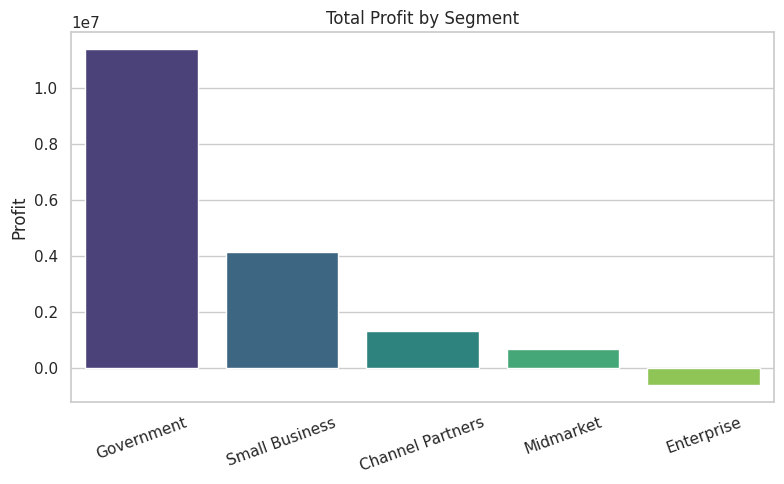

In [16]:
##6.Visualizations
os.makedirs("charts", exist_ok=True)   # folder to store chart images

# Chart 1: Profit by Segment
plt.figure(figsize=(8, 5))
sns.barplot(x=by_segment.index, y=by_segment["Profit"], palette="viridis")
plt.title("Total Profit by Segment"); plt.ylabel("Profit"); plt.xlabel("")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig("charts/profit_by_segment.png", dpi=150); plt.show()

/tmp/ipykernel_676/374897665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_country["Profit"], y=by_country.index, palette="mako")


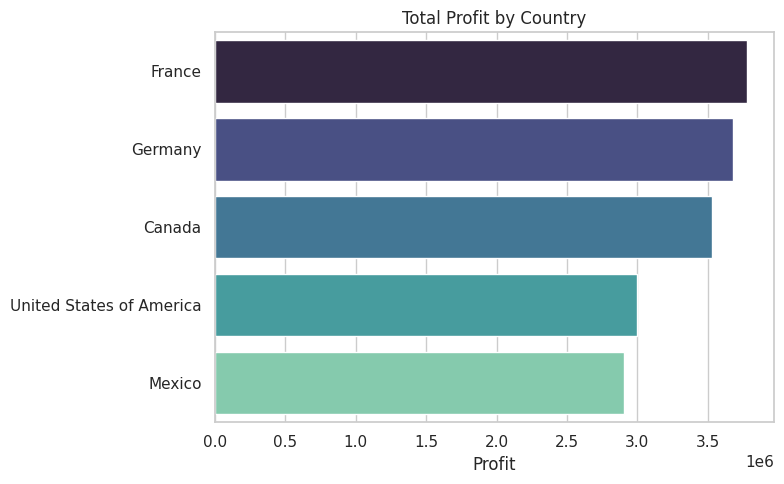

In [17]:
# Chart 2: Profit by Country
plt.figure(figsize=(8, 5))
sns.barplot(x=by_country["Profit"], y=by_country.index, palette="mako")
plt.title("Total Profit by Country"); plt.xlabel("Profit"); plt.ylabel("")
plt.tight_layout()
plt.savefig("charts/profit_by_country.png", dpi=150); plt.show()

/tmp/ipykernel_676/379673678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_product["Profit"], y=by_product.index, palette="rocket")


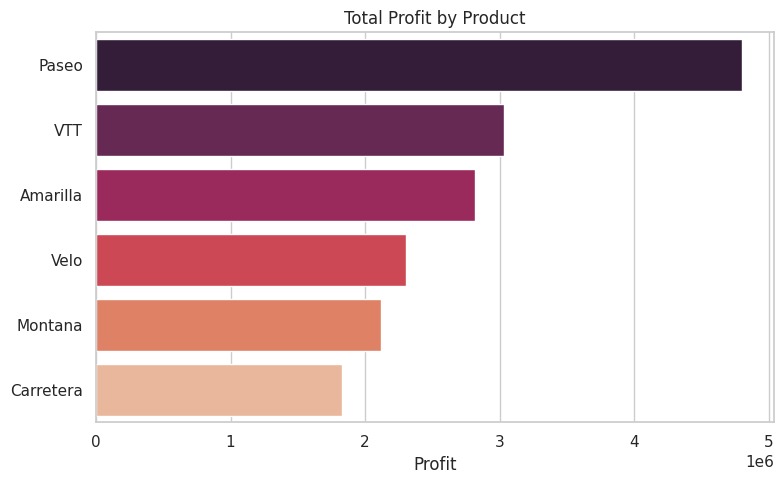

In [18]:
# Chart 3: Profit by Product
plt.figure(figsize=(8, 5))
sns.barplot(x=by_product["Profit"], y=by_product.index, palette="rocket")
plt.title("Total Profit by Product"); plt.xlabel("Profit"); plt.ylabel("")
plt.tight_layout()
plt.savefig("charts/profit_by_product.png", dpi=150); plt.show()

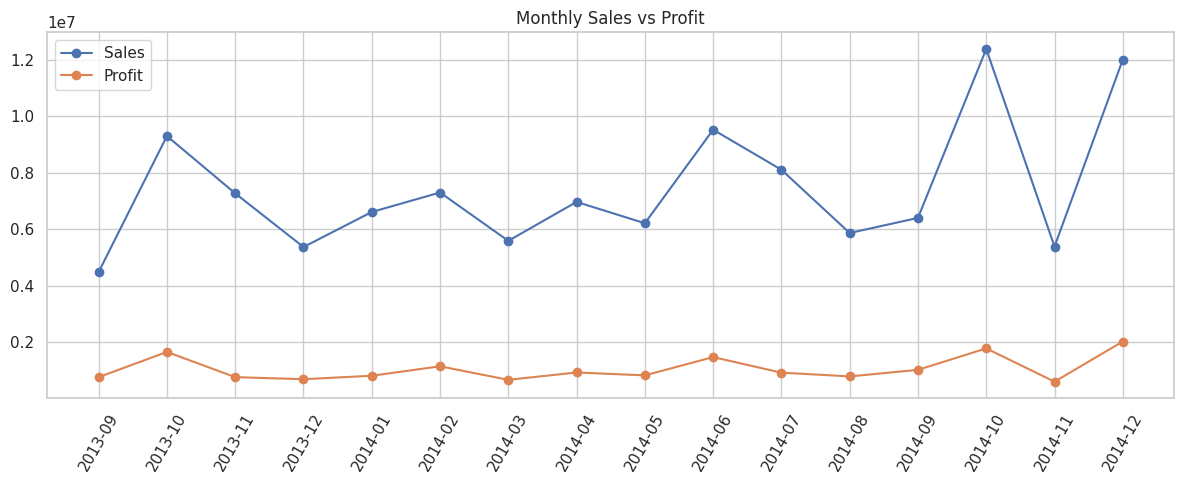

In [19]:
# Chart 4: Monthly Sales and Profit trend
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly["Sales"], marker="o", label="Sales")
plt.plot(monthly.index, monthly["Profit"], marker="o", label="Profit")
plt.title("Monthly Sales vs Profit"); plt.xticks(rotation=60); plt.legend()
plt.tight_layout()
plt.savefig("charts/monthly_trend.png", dpi=150); plt.show()

/tmp/ipykernel_676/1719718976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Discount_Band", y="Profit_Margin_%", order=order,


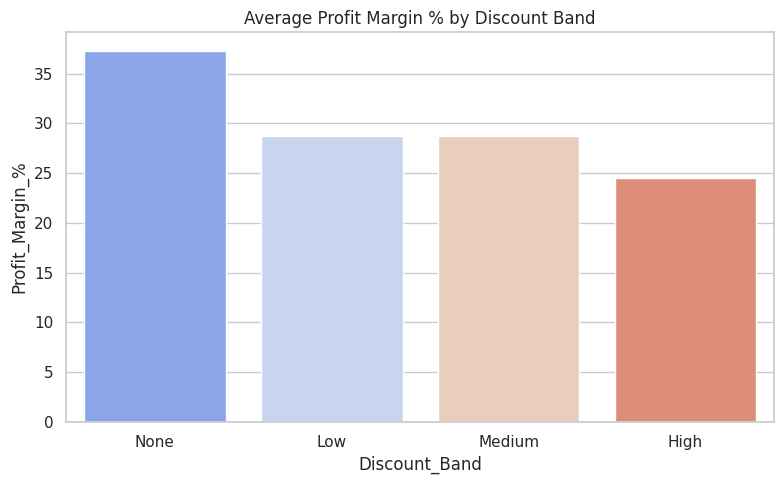

In [20]:
# Chart 5: Average profit margin by Discount Band
plt.figure(figsize=(8, 5))
order = ["None", "Low", "Medium", "High"]
order = [o for o in order if o in df["Discount_Band"].unique()]
sns.barplot(data=df, x="Discount_Band", y="Profit_Margin_%", order=order,
            estimator="mean", errorbar=None, palette="coolwarm")
plt.title("Average Profit Margin % by Discount Band")
plt.tight_layout()
plt.savefig("charts/margin_by_discount.png", dpi=150); plt.show()

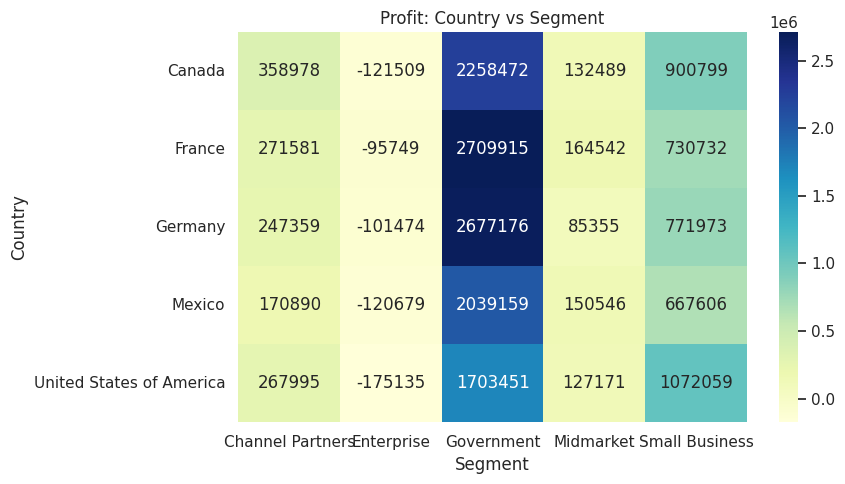

In [21]:
# Chart 6: Segment x Country profit heatmap
pivot = df.pivot_table(values="Profit", index="Country", columns="Segment", aggfunc="sum")
plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Profit: Country vs Segment"); plt.tight_layout()
plt.savefig("charts/heatmap_country_segment.png", dpi=150); plt.show()

In [22]:
##7.Export everything for Power BI, Excel and GitHub
df.to_csv("cleaned_sales_data.csv", index=False)   # use this file in Power BI and Excel

# Save summary tables into one Excel file (handy for your report)
with pd.ExcelWriter("analysis_summary.xlsx") as writer:
    by_segment.to_excel(writer, sheet_name="By Segment")
    by_country.to_excel(writer, sheet_name="By Country")
    by_product.to_excel(writer, sheet_name="By Product")
    by_discount.to_excel(writer, sheet_name="By Discount Band")
    by_year.to_excel(writer, sheet_name="By Year")
    monthly.to_excel(writer, sheet_name="Monthly")

# Bundle charts + files into one ZIP and download it
!zip -r project_outputs.zip charts cleaned_sales_data.csv analysis_summary.xlsx
files.download("project_outputs.zip")

  adding: charts/ (stored 0%)
  adding: charts/margin_by_discount.png (deflated 23%)
  adding: charts/profit_by_segment.png (deflated 20%)
  adding: charts/profit_by_product.png (deflated 27%)
  adding: charts/heatmap_country_segment.png (deflated 8%)
  adding: charts/profit_by_country.png (deflated 26%)
  adding: charts/monthly_trend.png (deflated 12%)
  adding: cleaned_sales_data.csv (deflated 78%)
  adding: analysis_summary.xlsx (deflated 11%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>